In [1]:
# Import necessary libraries
import numpy as np  # For numerical operations and arrays
import matplotlib.pyplot as plt  # For plotting
import random
import time  # For tracking execution time
import matplotlib.animation as animation  # Required for animation
from collections import deque  # For BFS implementation (queue)
from scipy.spatial import KDTree


#Identification of Obstacles
#Input: Map built (full of different nodes/neurons)
        

# Constants for point types
E = 100.0       # Large positive input for uncleaned areas
NEG_E = -100.0  # Large negative input for obstacles
CLEANED = 0.0   # Indicates a cleaned point
MU = 0.5        # Weight factor for neural connections
C = 1.0         # Direction preference weight

# Define the point structure
class Point:
    def __init__(self, x, y, z, activity=0, point_type=E):
        self.x = x
        self.y = y
        self.z = z
        self.activity = activity
        self.type = point_type  # Either E (normal), NEG_E (obstacle), or CLEANED
        self.neighbors = []
        

def generate_points(n, space_size):
    points = [Point(*coords) for coords in np.random.rand(n, 3) * space_size]
    
    # Assign some points as obstacles (10% of points)
    num_obstacles = max(1, n // 10)
    obstacle_indices = np.random.choice(n, size=num_obstacles, replace=False)
    for idx in obstacle_indices:
        points[idx].type = NEG_E
    
    return points

def build_kdtree(points):
    coords = np.array([[p.x, p.y, p.z] for p in points])
    tree = KDTree(coords)
    
    for i, p in enumerate(points):
        _, indices = tree.query([coords[i]], k=min(20, len(points)))  # Get 20 nearest neighbors
        p.neighbors = indices[0].tolist()

    return points


def distance(point1, point2):
    return np.sqrt((point2.x - point1.x) ** 2 + (point2.y - point1.y) ** 2 + (point2.z - point1.z) ** 2)   


def is_neighbour(tree_nodes):
    '''
    Main idea: For all the elements in the map, you select a node j and then you select one 
    of it's neighbors which will be the node i, then you look at it's positions
    
    We are planning to implement the function in 3.1.1

        Q_i = {j, |q_i - q_j| <= r}
        where q_i and q_j are the positions of the i-th and j-th point
        and r is the radius

        * It's important to mention that the radius is a threshold that defines which points are considered
        neighbors, if a point q_j is within the distance r from q_i, it is considered a neighbor of q_i

        * To calculate this radius, you can use an average of the point distance or you can set different
        individual radius for sections (given that some points can be very far from the other)

        **Update: For now, we are using a default radius (the size of the rover)
    '''

    '''
    What this function does: It takes as an input a KD tree, this tree consists on nodes with 20 neighbors (calculated in mapping.py)
    then, it uses BFS to traverse through each point and through each of it's neighbors and calculates the distance, if the distance is
    smaller than the threshold it appends this neighbor to a list called "valid_neighbors" which are the actual neighbors of that node
    (filtered from the previous 20 that there were before), after that, the neighbors of a node changes (from the 20 initial nodes,
    to the actual amount of neighbors that the node should have). And what is returned is a map with nodes and their particular 
    neighbors so we can work with them instead of the KD tree with all the connections

    The input map should be done of structs of points that have the following parameters:
    
            Struct point{
            point.x
            point.y
            point.z
            neighbors (this is a pointer}
    
    '''
    R = 44.8 #inches
    queue = deque([0]) #Start BFS from the first node (arbitrary choice)
    visited = set()
    filtered_map = {} #Store neighbors for each node

    while queue:
        node_idx = queue.popleft()

        if node_idx in visited:
            continue

        visited.add(node_idx)

        node = tree_nodes[node_idx]
        valid_neighbors = []
    
        for neighbor_idx in node.neighbors:  # Traverse precomputed 20 neighbors
                    neighbor = tree_nodes[neighbor_idx]  # Get neighbor node
                    if distance(node, neighbor) <= R:
                        valid_neighbors.append(neighbor_idx)

        filtered_map[node_idx] = valid_neighbors  # Store only valid neighbors

        for neighbor_idx in valid_neighbors:
            if neighbor_idx not in visited:
                queue.append(neighbor_idx)


    return filtered_map

def fit_plane_least_squares(points):
    """
    Fits a plane using least squares method for a set of neighboring points.
    
    Inputs:
        points: List of Point objects (neighbors of a node).
        
    Returns:
        normal_vector: The normal vector (n_i) of the fitted plane.
    """
    # Extract (x, y, z) coordinates
    A = np.array([[p.x, p.y, 1] for p in points])  # Add 1 for the constant term
    b = np.array([-p.z for p in points])  # Move z to the right-hand side
    
    # Solve for plane parameters (Ax + By + C = z) using Least Squares
    normal_vector, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    
    # The normal vector is (A, B, -1), normalized
    n = np.array([normal_vector[0], normal_vector[1], -1])
    n /= np.linalg.norm(n)  # Normalize the normal vector
    
    return n

def point_plane_distance(point, normal_vector):
    """
    Computes the perpendicular distance from a point to a plane.

    Inputs:
        point: A Point object.
        normal_vector: Normal vector (n_i) of the plane.
    
    Returns:
        Distance from point to plane.
    """
    numerator = abs(np.dot(normal_vector, np.array([point.x, point.y, point.z])) + 1)
    denominator = np.linalg.norm(normal_vector)
    
    return numerator / denominator

def detect_obstacles(tree_nodes, filtered_neighbors, d_threshold=5.0):
    """
    Identifies obstacle points based on their distance to the least squares fitted plane.

    Inputs:
        tree_nodes: List of Point objects.
        filtered_neighbors: Dictionary of valid neighbors per node.
        d_threshold: Maximum crossing height (default: 5.0 inches).
    
    Returns:
        obstacles: List of obstacle point indices.
    """
    obstacles = []
    
    for i, node in enumerate(tree_nodes):
        if len(filtered_neighbors[i]) < 3:  # Need at least 3 points to fit a plane
            continue
        
        # Get neighboring points
        neighbor_points = [tree_nodes[idx] for idx in filtered_neighbors[i]]

        # Fit a plane to neighbors
        normal_vector = fit_plane_least_squares(neighbor_points)

        # Compute distance from the node to the fitted plane
        d_i = point_plane_distance(node, normal_vector)

        # Mark as obstacle if distance exceeds threshold
        if d_i > d_threshold:
            obstacles.append(i)

    return obstacles


# Activation function f(x)
def activation_function(x):
    if x < -1:
        return -1
    elif x > 1:
        return 1
    return x

# Compute connection weight w_ij
def compute_weight(point_i, point_j, mu=0.5):
    """
    Compute the connection weight w_ij = mu / |q_i - q_j|
    Inputs:
        point_i: Point object
        point_j: Point object
        mu: Scaling factor (default 0.5)
    Returns:
        weight (float)
    """
    dist = np.linalg.norm(np.array([point_i.x, point_i.y, point_i.z]) - 
                          np.array([point_j.x, point_j.y, point_j.z]))
    return mu / dist if dist > 0 else 0

# Compute external input I_i
def compute_external_input(point, E=100.0):
    """
    Compute external input I_i based on the point type.
    Inputs:
        point: Point object
        E: Large positive input for uncovered points
    Returns:
        I_i (float)
    """
    if point.type == 0:  # Covered
        return 0
    elif point.type == -E:  # Obstacle
        return -E
    return E  # Uncleaned area

# Update neural activities
def update_activities(tree_nodes, filtered_neighbors, mu=0.5, E=100.0):
    """
    Updates the activity of each point in the filtered map based on its neighbors.
    Inputs:
        tree_nodes: List of Point objects
        filtered_neighbors: Dictionary of valid neighbors per node
        mu: Scaling factor for connection weights
        E: External input magnitude
    Returns:
        None (modifies the activity of each Point in-place)
    """
    new_activities = {}

    for i, point in enumerate(tree_nodes):
        sum_term = 0
        
        for j in filtered_neighbors[i]:
            neighbor = tree_nodes[j]
            w_ij = compute_weight(point, neighbor, mu)
            sum_term += w_ij * max(neighbor.activity, 0)  # [x_j]^+

        I_i = compute_external_input(point, E)

        # Compute new activity
        new_activity = activation_function(sum_term + I_i)
        new_activities[i] = new_activity

    # Update all activities after computation
    for i in new_activities:
        tree_nodes[i].activity = new_activities[i]


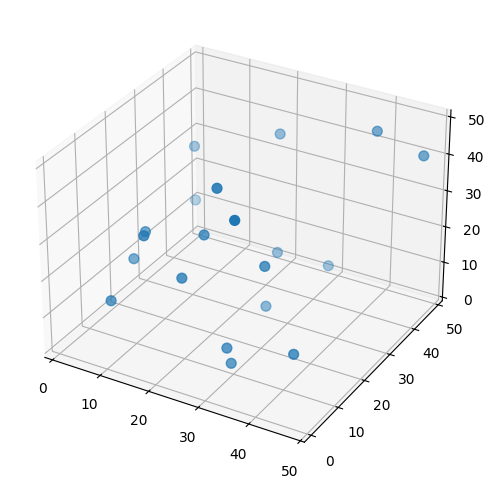

In [2]:
# Function to get the next position of the robot
def get_next_position(robot_idx, tree_nodes, filtered_neighbors):
    """
    Determines the next position of the robot by choosing the neighbor with the highest neural activity.
    
    Inputs:
        robot_idx: Current position index of the robot
        tree_nodes: List of Point objects
        filtered_neighbors: Dictionary of valid neighbors per node
    
    Returns:
        next_idx: Index of the next point for the robot
    """
    neighbors = filtered_neighbors[robot_idx]
    if not neighbors:
        return robot_idx  # Stay in place if no valid neighbors
    
    # Find the neighbor with the highest neural activity
    next_idx = max(neighbors, key=lambda idx: tree_nodes[idx].activity)
    
    return next_idx

# Function to update the plot during animation
def update_animation(frame, scatter, tree_nodes):
    """
    Updates the scatter plot with new colors based on neural activity.
    
    Inputs:
        frame: Current frame number (unused, but required by animation)
        scatter: The scatter plot object being updated
        tree_nodes: List of Point objects
    
    Returns:
        Updated scatter plot with new colors
    """
    # Compute new colors based on neural activity
    colors = []
    for point in tree_nodes:
        if point.type == NEG_E:
            colors.append("red")  # Obstacles are red
        elif point.type == CLEANED:
            colors.append("green")  # Cleaned points are green
        else:
            # Scale brightness by neural activity (normalized)
            activity_norm = (point.activity + 1) / 2  # Normalize activity between 0 and 1
            colors.append((activity_norm, activity_norm, activity_norm))  # Grayscale

    scatter.set_color(colors)
    return scatter,

# Function to run the animation
def run_animation(tree_nodes, filtered_neighbors, max_steps=50):
    """
    Runs an animation showing the robot moving through the neural field, updating activities as it moves.
    
    Inputs:
        tree_nodes: List of Point objects
        filtered_neighbors: Dictionary of valid neighbors per node
        max_steps: Maximum number of steps the robot can take
    
    Returns:
        Matplotlib animation object
    """
    # Initialize figure
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Get initial coordinates
    coords = np.array([[p.x, p.y, p.z] for p in tree_nodes])

    # Create scatter plot
    scatter = ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], s=50)

    # Initialize robot at a random non-obstacle point
    available_points = [i for i, p in enumerate(tree_nodes) if p.type != NEG_E]
    robot_idx = random.choice(available_points)

    def update(frame):
        """
        Updates the robot position, cleans the current node, and updates neural activity.
        """
        nonlocal robot_idx
        
        # Mark current position as cleaned
        tree_nodes[robot_idx].type = CLEANED

        # Update neural activities
        update_activities(tree_nodes, filtered_neighbors)

        # Get next position for the robot
        robot_idx = get_next_position(robot_idx, tree_nodes, filtered_neighbors)

        # Update scatter plot colors
        return update_animation(frame, scatter, tree_nodes)

    # Run animation
    ani = animation.FuncAnimation(fig, update, frames=max_steps, interval=500, repeat=False)

    plt.show()
    return ani

# Run the animation with a small test case
np.random.seed(42)
num_points = 20  # Small test case for animation
space_size = 50
tree_nodes = generate_points(num_points, space_size)
tree_nodes = build_kdtree(tree_nodes)

# Compute filtered neighbors
filtered_neighbors = is_neighbour(tree_nodes)

# Run the animation
run_animation(tree_nodes, filtered_neighbors, max_steps=30)
